In [28]:
import scqubits
import numpy as np
from scipy.optimize import minimize

EJ = 2.6
EC = 0.75
EL = 0.15

qubit_level = 30

def get_shift(ele,Delta_ij):
    return abs(ele)**2 / Delta_ij

qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff_input_Er(x):
    Er = x
    shifts_from_one = [get_shift(elements[1,ql2],evals[ql2]-evals[1]-Er) for ql2 in range(qubit_level)] 
    shift_from_one= sum(shifts_from_one)
    shifts_from_two = [get_shift(elements[2,ql2],evals[ql2]-evals[2]-Er) for ql2 in range(qubit_level)] 
    shift_from_two = sum(shifts_from_two)
    return abs(shift_from_one-shift_from_two)

initial_guess = [7.2]
bounds = [(7,7.4)]
# Call the optimizer
result = minimize(shift_diff_input_Er, initial_guess, method='Nelder-Mead',bounds=bounds)

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.755667903754256e-07
             x: [ 7.186e+00]
           nit: 12
          nfev: 25
 final_simplex: (array([[ 7.186e+00],
                       [ 7.187e+00]]), array([ 3.756e-07,  6.743e-07]))
Optimal solution: [7.18642578]
Objective value: 3.755667903754256e-07



qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.0767925829161129
qbt freq at osc 1:	0.07703, 	diff to at osc ground 0.00024, 0.3095% diff
qbt freq at osc 2:	0.07718, 	diff to at osc ground 0.00039, 0.5073% diff
qbt freq at osc 3:	0.07727, 	diff to at osc ground 0.00048, 0.6270% diff
qbt freq at osc 4:	0.07736, 	diff to at osc ground 0.00057, 0.7361% diff
qbt freq at osc 5:	0.07753, 	diff to at osc ground 0.00074, 0.9656% diff
qbt freq at osc 6:	0.07800, 	diff to at osc ground 0.00121, 1.5731% diff
qbt freq at osc 7:	0.07915, 	diff to at osc ground 0.00236, 3.0678% diff
qbt freq at osc 8:	0.08168, 	diff to at osc ground 0.00488, 6.3604% diff
qbt freq at osc 9:	0.08641, 	diff to at osc ground 0.00961, 12.5204% diff
qbt freq at osc 10:	0.05518, 	diff to at osc ground -0.02161, 28.1423% diff
qbt freq at osc 11:	0.05594, 	diff to at osc ground -0.02086, 27.1609% diff
qbt freq at osc 12:	0.05533, 	diff to at osc ground -0.02147, 27.9530% diff
qb

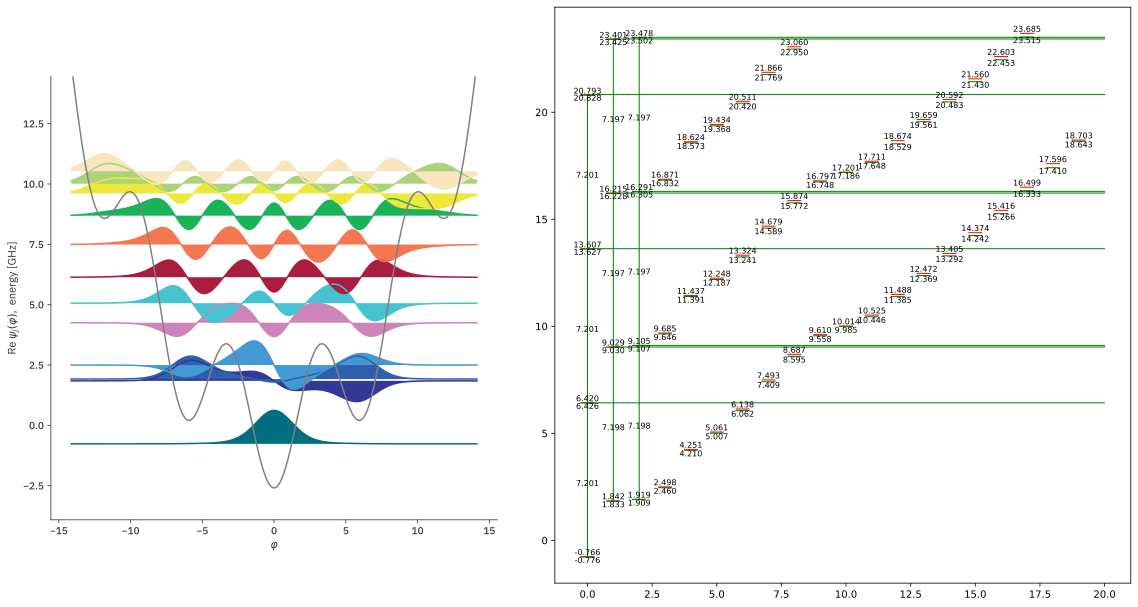

In [31]:
from utils import *

system = fluxonium_oscillator_system(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = result.x[0],
    g_strength = 0.6,
    qubit_level = 20,
    osc_level = 20,
    kappa = 0.001,
    products_to_keep=[[ql, ol] for ql in range(20) for ol in range(20) ]
    )


energies=  system.hilbertspace.eigenvals(system.qubit_level*system.osc_level)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,system.osc_level-1):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,system.osc_level-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

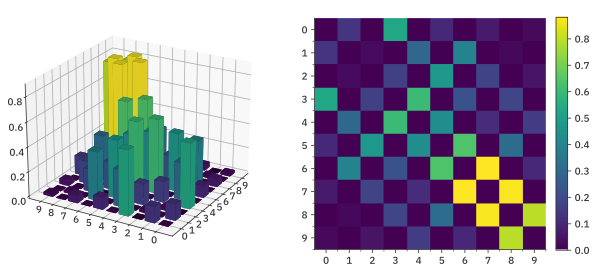

In [ ]:
system.qbt.plot_matrixelements('n_operator',evals_count = 10)